In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
np.random.seed(42)

m = 3.5
c = 2.0
n_samples = 10000

X = np.random.uniform(-10, 10, n_samples)
noise = np.random.normal(0, 2, n_samples)
y = m * X + c + noise

X = X.reshape(-1, 1)


In [3]:
split = int(0.8 * n_samples)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [4]:
X_train_bias = np.c_[np.ones(len(X_train)), X_train]
X_test_bias = np.c_[np.ones(len(X_test)), X_test]

theta_ls = np.linalg.inv(X_train_bias.T @ X_train_bias) @ X_train_bias.T @ y_train

y_pred_linear = X_test_bias @ theta_ls


In [5]:
degree = 3

X_poly_train = np.hstack([X_train ** i for i in range(degree + 1)])
X_poly_test = np.hstack([X_test ** i for i in range(degree + 1)])

theta_poly = np.linalg.inv(X_poly_train.T @ X_poly_train) @ X_poly_train.T @ y_train
y_pred_poly = X_poly_test @ theta_poly


In [6]:
# Linear
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

# Polynomial
mse_poly = mean_squared_error(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)

print("Linear Regression:")
print("MSE:", mse_linear)
print("MAE:", mae_linear)

print("\nPolynomial Regression:")
print("MSE:", mse_poly)
print("MAE:", mae_poly)


Linear Regression:
MSE: 3.981188634749629
MAE: 1.594909204818694

Polynomial Regression:
MSE: 3.989293945893184
MAE: 1.596305063708603


In [7]:
lr = 0.001
epochs = 1000

theta_gd = np.zeros(2)

for _ in range(epochs):
    y_pred = X_train_bias @ theta_gd
    error = y_pred - y_train
    gradients = (2 / len(X_train)) * X_train_bias.T @ error
    theta_gd -= lr * gradients

y_pred_gd = X_test_bias @ theta_gd


In [8]:
mse_gd = mean_squared_error(y_test, y_pred_gd)
mae_gd = mean_absolute_error(y_test, y_pred_gd)

print("\nGradient Descent Linear Regression:")
print("MSE:", mse_gd)
print("MAE:", mae_gd)



Gradient Descent Linear Regression:
MSE: 4.080500621307212
MAE: 1.6182235997688759


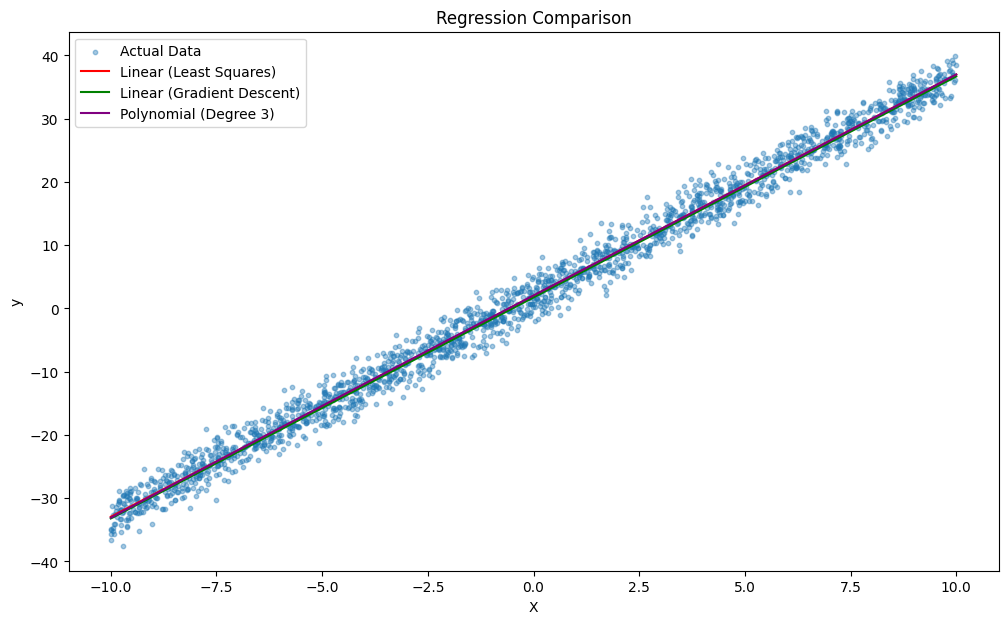

In [9]:
X_plot = np.linspace(-10, 10, 500).reshape(-1, 1)
X_plot_bias = np.c_[np.ones(len(X_plot)), X_plot]
X_plot_poly = np.hstack([X_plot ** i for i in range(degree + 1)])

plt.figure(figsize=(12, 7))
plt.scatter(X_test, y_test, s=10, alpha=0.4, label="Actual Data")

plt.plot(X_plot, X_plot_bias @ theta_ls, color='red', label="Linear (Least Squares)")
plt.plot(X_plot, X_plot_bias @ theta_gd, color='green', label="Linear (Gradient Descent)")
plt.plot(X_plot, X_plot_poly @ theta_poly, color='purple', label="Polynomial (Degree 3)")

plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regression Comparison")
plt.show()
